# Regional `FastARGTrace` boundary-state replay

This notebook runs the two-stage region workflow for the 25 kb and 1 Mb fixtures, builds exactly one immutable `FastARGTrace` per fixture, and creates an independent mutable `FastARGState` at every valid Stage-2 witness boundary.

The stored boundary states are never moved during inspection. Interactive replay always operates on a clone, and regional events come from the witness certificate's global event indices rather than from genomic-overlap filtering. Local replacement and splice-back are deliberately outside this milestone.

## Workflow

```text
normal tree sequence
  -> Stage 1 incremental edge-closed regions
  -> balanced synthetic/full ARG with unique event times
  -> one shared FastARGTrace
  -> Stage 2 incremental exact witness scan
  -> one independent boundary FastARGState per valid region
  -> cloned regional inspection and terminal replay
```

In [1]:
from pathlib import Path
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=r"Pandas requires version .* of 'numexpr'")
    import pandas as pd
import tskit
from IPython.display import display

def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start).expanduser().resolve()
    fallback = Path("/Users/pratik/Documents/work/aim3/simpliied")
    for candidate in (start, *start.parents, fallback):
        if (candidate / "arg/new_rl/trace.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the workspace root")

WORKSPACE_ROOT = find_workspace_root()
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from arg.new_rl.exact_closed_cones import (
    assert_synthetic_endpoints_are_normal_breakpoints,
    scan_exact_region_witnesses,
)
from arg.new_rl.normal_ts_edge_closed_regions import (
    scan_normal_ts_edge_closed_regions,
)
from arg.new_rl.synthetic_full_arg import build_synthetic_full_arg
from arg.new_rl.trace import build_fast_trace_from_full_arg

FIXTURE_PATHS = {
    "25 kb": WORKSPACE_ROOT / "arg/validation/output/tsinfer/l25kb_dated.trees",
    "1 Mb": WORKSPACE_ROOT / "arg/validation/output/tsinfer/l1mb_dated.trees",
}
for fixture_path in FIXTURE_PATHS.values():
    if not fixture_path.is_file():
        raise FileNotFoundError(fixture_path)

FIXTURE_PATHS

{'25 kb': PosixPath('/Users/pratik/Documents/work/aim3/simpliied/arg/validation/output/tsinfer/l25kb_dated.trees'),
 '1 Mb': PosixPath('/Users/pratik/Documents/work/aim3/simpliied/arg/validation/output/tsinfer/l1mb_dated.trees')}

## Build the shared traces and exact witnesses

Both discovery stages use their incremental implementations. Each fixture dictionary owns one synthetic ARG and one shared trace; regional contexts created later only add mutable replay state.

In [2]:
fixture_pipelines = {}
for fixture, fixture_path in FIXTURE_PATHS.items():
    normal_ts = tskit.load(str(fixture_path))

    stage_1_started = time.perf_counter()
    stage_1 = scan_normal_ts_edge_closed_regions(
        normal_ts, algorithm="incremental"
    )
    stage_1_seconds = time.perf_counter() - stage_1_started

    conversion_started = time.perf_counter()
    conversion = build_synthetic_full_arg(
        normal_ts,
        split_rule="balanced",
        ensure_unique_event_times=True,
    )
    conversion_seconds = time.perf_counter() - conversion_started
    synthetic_arg = conversion.tree_sequence
    assert_synthetic_endpoints_are_normal_breakpoints(normal_ts, synthetic_arg)

    trace_started = time.perf_counter()
    trace = build_fast_trace_from_full_arg(
        synthetic_arg, require_unique_event_times=True
    )
    trace_seconds = time.perf_counter() - trace_started
    assert trace.num_steps <= 1 or np.all(np.diff(trace.event_time) > 0.0)

    stage_2_started = time.perf_counter()
    stage_2 = scan_exact_region_witnesses(
        trace, stage_1.regions, algorithm="incremental"
    )
    stage_2_seconds = time.perf_counter() - stage_2_started

    fixture_pipelines[fixture] = {
        "normal_ts": normal_ts,
        "stage_1": stage_1,
        "conversion": conversion,
        "synthetic_arg": synthetic_arg,
        "trace": trace,
        "stage_2": stage_2,
        "timings": {
            "stage_1_seconds": stage_1_seconds,
            "conversion_seconds": conversion_seconds,
            "trace_seconds": trace_seconds,
            "stage_2_seconds": stage_2_seconds,
        },
    }

pipeline_summary_df = pd.DataFrame(
    [
        {
            "fixture": fixture,
            "sequence_length": pipeline["trace"].sequence_length,
            "samples": pipeline["normal_ts"].num_samples,
            "trace_events": pipeline["trace"].num_steps,
            "trace_edges": pipeline["trace"].edge_parent.size,
            "stage_1_regions": len(pipeline["stage_1"].regions),
            "stage_2_valid": len(pipeline["stage_2"].valid_witnesses),
            **pipeline["timings"],
        }
        for fixture, pipeline in fixture_pipelines.items()
    ]
)
display(pipeline_summary_df)

,fixture,sequence_length,samples,trace_events,trace_edges,stage_1_regions,stage_2_valid,stage_1_seconds,conversion_seconds,trace_seconds,stage_2_seconds
0,25 kb,25000.0,8,25,65,2,1,0.003021,0.001393,0.279032,0.009439
1,1 Mb,1000000.0,8,1801,7964,32,25,0.110588,0.010810,0.000319,4.866426


## Create independent regional boundary states

`region_trace_contexts[fixture][region_id]` is the main reusable live-object interface. The trace reference is shared within a fixture; every `boundary_state` is a distinct mutable object positioned at the selected exact witness cut. Certificate IDs remain global so a later local reconstruction can reconnect to the same synthetic ARG.

In [3]:
region_trace_contexts = {}
for fixture, pipeline in fixture_pipelines.items():
    shared_fast_trace = pipeline["trace"]
    fixture_contexts = {}
    for stage_2_region in pipeline["stage_2"].valid_witnesses:
        witness_certificate = stage_2_region["witness"]
        witness_cut_step = int(stage_2_region["witness_cut_step"])
        independent_boundary_state = (
            shared_fast_trace.initial_state().advance_to(witness_cut_step)
        )
        region_id = stage_2_region["region_id"]
        fixture_contexts[region_id] = {
            "trace": shared_fast_trace,
            "boundary_state": independent_boundary_state,
            "region": stage_2_region,
            "witness": witness_certificate,
            "event_indices": tuple(witness_certificate["suffix_event_indices"]),
            "node_ids": tuple(witness_certificate["node_ids"]),
            "edge_ids": tuple(witness_certificate["edge_ids"]),
            "frontier_segments": tuple(witness_certificate["frontier_segments"]),
            "terminal_attachment_ids": tuple(witness_certificate["terminal_lineage_ids"]),
        }
    region_trace_contexts[fixture] = fixture_contexts

{fixture: len(contexts) for fixture, contexts in region_trace_contexts.items()}

{'25 kb': 1, '1 Mb': 25}

In [4]:
region_summary_rows = []
for fixture, contexts in region_trace_contexts.items():
    for region_id, context in contexts.items():
        region = context["region"]
        witness = context["witness"]
        region_summary_rows.append(
            {
                "fixture": fixture,
                "region_id": region_id,
                "left": region["left"],
                "right": region["right"],
                "span": region["span"],
                "witness_step": region["witness_cut_step"],
                "witness_time": region["witness_cut_time"],
                "frontier_nodes": region["witness_frontier_node_count"],
                "internal_events": region["witness_internal_event_count"],
                "component_nodes": len(witness["node_ids"]),
                "component_edges": len(witness["edge_ids"]),
                "terminal_attachments": len(witness["terminal_lineage_ids"]),
            }
        )

region_trace_summary_df = pd.DataFrame(region_summary_rows).sort_values(
    ["fixture", "left", "right"]
).reset_index(drop=True)
for fixture in FIXTURE_PATHS:
    print(fixture)
    display(region_trace_summary_df.loc[region_trace_summary_df["fixture"] == fixture])

25 kb


,fixture,region_id,left,right,span,witness_step,witness_time,frontier_nodes,internal_events,component_nodes,component_edges,terminal_attachments
25,25 kb,normal-edge-region-0000,386.0,23963.0,23577.0,17,24677.10613,5,8,17,20,5


1 Mb


,fixture,region_id,left,right,span,witness_step,witness_time,frontier_nodes,internal_events,component_nodes,component_edges,terminal_attachments
0,1 Mb,normal-edge-region-0000,892.0,999859.0,998967.0,910,5480.167654,638,891,2062,2762,144
1,1 Mb,normal-edge-region-0013,5922.0,6564.0,642.0,1775,48080.880729,2,1,3,2,1
2,1 Mb,normal-edge-region-0007,110932.0,119529.0,8597.0,1673,29097.394003,2,1,3,2,1
3,1 Mb,normal-edge-region-0014,134074.0,134602.0,528.0,1776,48657.872871,2,1,3,2,1
4,1 Mb,normal-edge-region-0009,153474.0,157894.0,4420.0,1800,74789.489570,3,1,4,3,1
5,1 Mb,normal-edge-region-0027,171264.0,173036.0,1772.0,1787,53326.622150,3,1,4,3,1
6,1 Mb,normal-edge-region-0023,182998.0,185306.0,2308.0,1795,58108.074208,2,1,3,2,1
7,1 Mb,normal-edge-region-0024,211982.0,225923.0,13941.0,1785,52471.571067,10,1,11,10,1
8,1 Mb,normal-edge-region-0005,349767.0,351270.0,1503.0,1646,26087.940643,4,3,8,7,2
9,1 Mb,normal-edge-region-0018,350818.0,351270.0,452.0,1780,49713.849008,3,1,4,3,1


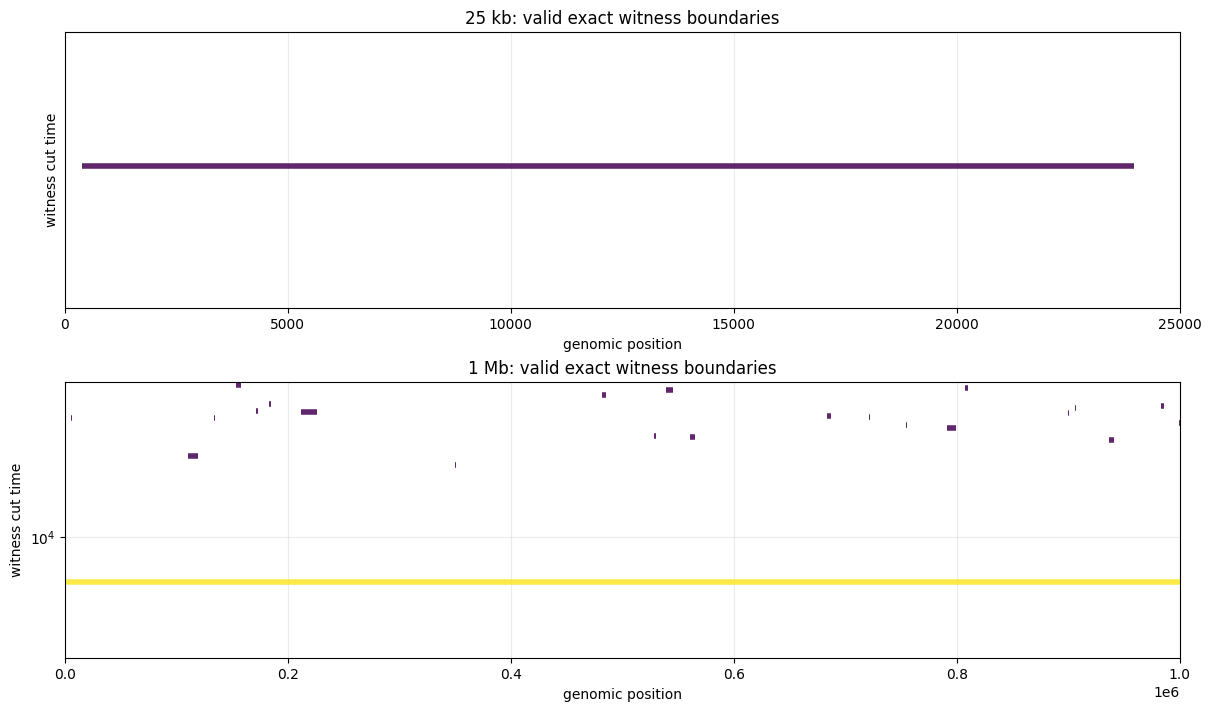

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
for axis, fixture in zip(axes, FIXTURE_PATHS):
    contexts = region_trace_contexts[fixture]
    event_counts = np.asarray(
        [context["witness"]["event_count"] for context in contexts.values()]
    )
    normalizer = plt.Normalize(
        vmin=int(event_counts.min()),
        vmax=max(int(event_counts.max()), int(event_counts.min()) + 1),
    )
    for context in contexts.values():
        region = context["region"]
        axis.hlines(
            region["witness_cut_time"],
            region["left"],
            region["right"],
            color=plt.cm.viridis(normalizer(context["witness"]["event_count"])),
            linewidth=4,
            alpha=0.85,
        )
    axis.set_xlim(0.0, fixture_pipelines[fixture]["trace"].sequence_length)
    axis.set_yscale("symlog", linthresh=1.0)
    axis.set_title(f"{fixture}: valid exact witness boundaries")
    axis.set_xlabel("genomic position")
    axis.set_ylabel("witness cut time")
    axis.grid(alpha=0.25)
plt.show()

## Regional event catalogs

Each row maps a region-local order to the original zero-based trace event index and the resulting one-based replay step. These catalogs use only `witness['suffix_event_indices']`; an unrelated edge that happens to overlap the same genomic window cannot become a regional event.

In [ ]:
def build_region_event_catalog(context):
    trace = context["trace"]
    rows = []
    for local_event_order, global_event_index in enumerate(context["event_indices"]):
        event = trace.event_at_index(global_event_index)
        rows.append(
            {
                "local_event_order": local_event_order,
                "global_event_index": global_event_index,
                "target_step": global_event_index + 1,
                "time": event.time,
                "kind": event.kind,
                "node_ids": event.node_ids,
                "edge_ids": event.edge_ids,
                "edge_count": len(event.edge_ids),
            }
        )
    return pd.DataFrame(rows)

region_event_catalogs = {
    fixture: {
        region_id: build_region_event_catalog(context)
        for region_id, context in contexts.items()
    }
    for fixture, contexts in region_trace_contexts.items()
}

for fixture, catalogs in region_event_catalogs.items():
    preview = pd.concat(
        [catalog.assign(region_id=region_id) for region_id, catalog in catalogs.items()],
        ignore_index=True,
    )
    print(f"{fixture}: {len(preview)} certified regional events (first 12 shown)")
    display(preview.head(12))

25 kb: 8 certified regional events (first 12 shown)


,local_event_order,global_event_index,target_step,time,kind,node_ids,edge_ids,edge_count,region_id
0,0,17,18,27617.469048,recombination,"(40, 41)","(45, 46, 47, 48)",4,normal-edge-region-0000
1,1,18,19,30557.831966,recombination,"(42, 43)","(49, 50)",2,normal-edge-region-0000
2,2,19,20,30690.071020,recombination,"(38, 39)","(51, 52)",2,normal-edge-region-0000
3,3,20,21,33498.194884,coalescence,"(16,)","(53, 54, 55)",3,normal-edge-region-0000
4,4,21,22,38946.101470,recombination,"(44, 45)","(56, 57)",2,normal-edge-region-0000
5,5,22,23,50274.733893,coalescence,"(18,)","(58, 59)",2,normal-edge-region-0000
6,6,23,24,58442.228572,coalescence,"(19,)","(60, 61)",2,normal-edge-region-0000
7,7,24,25,59996.982108,coalescence,"(17,)","(62, 63, 64)",3,normal-edge-region-0000


1 Mb: 917 certified regional events (first 12 shown)


,local_event_order,global_event_index,target_step,time,kind,node_ids,edge_ids,edge_count,region_id
0,0,910,911,5487.792697,recombination,"(2845, 2846)","(5202, 5203, 5204)",3,normal-edge-region-0000
1,1,911,912,5492.530650,recombination,"(2225, 2226)","(5205, 5206)",2,normal-edge-region-0000
2,2,912,913,5522.588876,recombination,"(2853, 2854)","(5207, 5208, 5209, 5210, 5211, 5212)",6,normal-edge-region-0000
3,3,913,914,5532.142553,coalescence,"(212,)","(5213, 5214, 5215)",3,normal-edge-region-0000
4,4,914,915,5558.220800,recombination,"(2251, 2252)","(5216, 5217)",2,normal-edge-region-0000
5,5,915,916,5585.335743,recombination,"(1249, 1250)","(5218, 5219)",2,normal-edge-region-0000
6,6,916,917,5594.265717,coalescence,"(74,)","(5220, 5221)",2,normal-edge-region-0000
7,7,917,918,5607.364009,coalescence,"(181,)","(5222, 5223, 5224, 5225, 5226, 5227, 5228, 5229)",8,normal-edge-region-0000
8,8,918,919,5607.364009,recombination,"(2645, 2646)","(5230, 5231, 5232, 5233, 5234, 5235, 5236)",7,normal-edge-region-0000
9,9,919,920,5607.364009,recombination,"(2651, 2652)","(5237, 5238, 5239, 5240)",4,normal-edge-region-0000


## Select and inspect one regional event

Change the three selectors below. The inspection state is cloned from the stored boundary state, moved to `global_event_index + 1`, and used to materialize a graph restricted to the region's half-open genomic interval.

In [7]:
SELECTED_FIXTURE = "25 kb"
SELECTED_REGION_ID = next(iter(region_trace_contexts[SELECTED_FIXTURE]))
SELECTED_LOCAL_EVENT = 0

selected_context = region_trace_contexts[SELECTED_FIXTURE][SELECTED_REGION_ID]
selected_catalog = region_event_catalogs[SELECTED_FIXTURE][SELECTED_REGION_ID]
if not 0 <= SELECTED_LOCAL_EVENT < len(selected_catalog):
    raise IndexError("SELECTED_LOCAL_EVENT is outside this region's event catalog")

selected_catalog_row = selected_catalog.iloc[SELECTED_LOCAL_EVENT]
selected_global_event_index = int(selected_catalog_row["global_event_index"])
selected_event = selected_context["trace"].event_at_index(
    selected_global_event_index
)
inspection_state = selected_context["boundary_state"].clone()
inspection_state.advance_to(selected_global_event_index + 1)
selected_region = selected_context["region"]
selected_region_graph = selected_context["trace"].graph_at_step(
    inspection_state.step,
    genomic_range=(selected_region["left"], selected_region["right"]),
)

display(selected_catalog_row.to_frame(name="selected_event"))
display(pd.Series(selected_region_graph["metadata"], name="windowed_graph").to_frame())
selected_region_graph

,selected_event
local_event_order,0
global_event_index,17
target_step,18
time,27617.469048
kind,recombination
node_ids,"(40, 41)"
edge_ids,"(45, 46, 47, 48)"
edge_count,4


,windowed_graph
step,18
current_time,27617.469048
genomic_range,"[386.0, 23963.0]"
visible_node_count,36
visible_edge_count,49
event_count,25


{'nodes': [{'id': 0,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 1,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 2,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 3,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 4,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 5,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 6,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 7,
   'time': 0.0,
   'flags': 1,
   'is_sample': True,
   'is_recombination': False},
  {'id': 8,
   'time': 1888.8971037242363,
   'flags': 0,
   'is_sample': False,
   'is_recombination': False},
  {'id': 9,
   'time': 1732.484917088363,
   'flags': 0,
   'is_sample': False,
   'is_recombination': False},


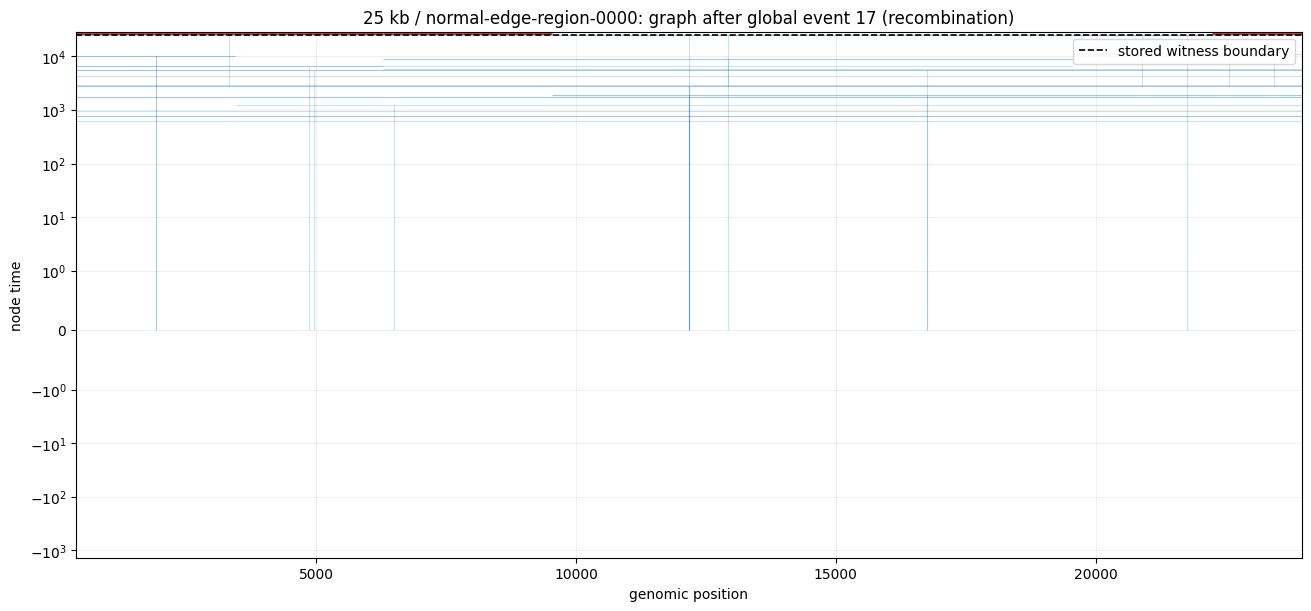

In [8]:
def plot_windowed_arg_graph(trace, graph, highlighted_edge_ids=()):
    highlighted_edge_ids = set(int(edge_id) for edge_id in highlighted_edge_ids)
    fig, axis = plt.subplots(figsize=(13, 6), constrained_layout=True)
    for edge in graph["edges"]:
        edge_id = int(edge["id"])
        left = float(edge["left"])
        right = float(edge["right"])
        parent_time = float(trace.node_time[int(edge["source"])])
        child_time = float(trace.node_time[int(edge["target"])])
        midpoint = 0.5 * (left + right)
        highlighted = edge_id in highlighted_edge_ids
        color = "tab:red" if highlighted else "tab:blue"
        alpha = 0.95 if highlighted else 0.22
        width = 2.2 if highlighted else 0.8
        axis.hlines(parent_time, left, right, color=color, alpha=alpha, linewidth=width)
        axis.vlines(midpoint, child_time, parent_time, color=color, alpha=alpha, linewidth=width)
    axis.axhline(
        selected_context["witness"]["boundary_time"],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="stored witness boundary",
    )
    axis.set_xlim(selected_region["left"], selected_region["right"])
    axis.set_yscale("symlog", linthresh=1.0)
    axis.set_xlabel("genomic position")
    axis.set_ylabel("node time")
    axis.set_title(
        f"{SELECTED_FIXTURE} / {SELECTED_REGION_ID}: graph after global event "
        f"{selected_global_event_index} ({selected_event.kind})"
    )
    axis.grid(alpha=0.18)
    axis.legend()
    return fig, axis


plot_windowed_arg_graph(
    selected_context["trace"],
    selected_region_graph,
    highlighted_edge_ids=selected_event.edge_ids,
)
plt.show()

## Boundary-certificate and replay validation

The checks below validate exact boundary placement, frontier material, event/edge identity, half-open containment, terminal attachments, full terminal replay, shared trace identity, and independent mutable state.

In [9]:
def frontier_signature(state, selected_node_ids=None):
    frontier = state.compact_active_frontier()
    selected = None if selected_node_ids is None else set(map(int, selected_node_ids))
    rows = []
    for lineage_index, node_id in enumerate(frontier.node_ids):
        node_id = int(node_id)
        if selected is not None and node_id not in selected:
            continue
        for left, right in frontier.segments_for_index(lineage_index):
            rows.append((node_id, float(left), float(right)))
    return tuple(sorted(rows))


expected_stage_1_counts = {"25 kb": 2, "1 Mb": 32}
expected_stage_2_counts = {"25 kb": 1, "1 Mb": 25}
validation_rows = []

for fixture, pipeline in fixture_pipelines.items():
    trace = pipeline["trace"]
    contexts = region_trace_contexts[fixture]
    assert len(pipeline["stage_1"].regions) == expected_stage_1_counts[fixture]
    assert len(pipeline["stage_2"].valid_witnesses) == expected_stage_2_counts[fixture]
    assert pipeline["stage_2"].diagnostics["event_insertions"] == trace.num_steps
    assert pipeline["stage_2"].diagnostics["edge_insertions"] == trace.revealed_edge_ids.size
    assert pipeline["stage_2"].diagnostics["suffix_rebuilds"] == 0

    terminal_state = trace.initial_state().advance_to(trace.num_steps)
    terminal_signature = frontier_signature(terminal_state)
    state_object_ids = []
    for region_id, context in contexts.items():
        region = context["region"]
        witness = context["witness"]
        boundary_state = context["boundary_state"]
        state_object_ids.append(id(boundary_state))

        assert context["trace"] is trace
        assert boundary_state.trace is trace
        assert boundary_state.step == witness["boundary_step"] == region["witness_cut_step"]
        assert np.isclose(boundary_state.current_time, witness["boundary_time"])
        assert np.isclose(boundary_state.current_time, region["witness_cut_time"])
        assert witness["exact"] and witness["closure_verified"]
        assert not witness["outside_overlap_edge_ids"]

        anchor_ids = tuple(witness["lower_frontier_anchor_node_ids"])
        assert set(anchor_ids).issubset(set(map(int, boundary_state.compact_active_frontier().node_ids)))
        assert frontier_signature(boundary_state, anchor_ids) == tuple(sorted(witness["frontier_segments"]))
        assert context["frontier_segments"] == tuple(witness["frontier_segments"])

        event_indices = tuple(context["event_indices"])
        assert event_indices == tuple(witness["suffix_event_indices"])
        event_edge_union = tuple(
            sorted(
                {
                    int(edge_id)
                    for event_index in event_indices
                    for edge_id in trace.event_at_index(event_index).edge_ids
                }
            )
        )
        assert event_edge_union == tuple(sorted(witness["edge_ids"]))
        assert len(event_indices) == witness["event_count"]

        edge_ids = np.asarray(witness["edge_ids"], dtype=np.int64)
        assert edge_ids.size > 0
        assert np.all(trace.edge_left[edge_ids] >= float(region["left"]))
        assert np.all(trace.edge_right[edge_ids] <= float(region["right"]))
        assert np.all(trace.edge_left[edge_ids] < trace.edge_right[edge_ids])
        assert set(witness["node_ids"]).issubset(set(range(trace.node_time.size)))

        terminal_attachment_ids = tuple(witness["terminal_lineage_ids"])
        assert terminal_attachment_ids
        assert context["terminal_attachment_ids"] == terminal_attachment_ids
        assert set(terminal_attachment_ids).issubset(
            set(map(int, terminal_state.compact_active_frontier().node_ids))
        )

        stored_step = boundary_state.step
        stored_signature = frontier_signature(boundary_state)
        replay_state = boundary_state.clone().advance_to(trace.num_steps)
        assert replay_state.step == trace.num_steps
        assert replay_state.current_time == terminal_state.current_time
        assert frontier_signature(replay_state) == terminal_signature
        assert boundary_state.step == stored_step
        assert frontier_signature(boundary_state) == stored_signature

        validation_rows.append(
            {
                "fixture": fixture,
                "region_id": region_id,
                "boundary_step": stored_step,
                "terminal_step": replay_state.step,
                "events": len(event_indices),
                "edges": len(edge_ids),
                "status": "passed",
            }
        )

    assert len(state_object_ids) == len(set(state_object_ids))
    before = tuple(
        (context["boundary_state"].step, frontier_signature(context["boundary_state"]))
        for context in contexts.values()
    )
    first_context = next(iter(contexts.values()))
    first_context["boundary_state"].clone().advance_to(trace.num_steps)
    after = tuple(
        (context["boundary_state"].step, frontier_signature(context["boundary_state"]))
        for context in contexts.values()
    )
    assert before == after

validation_df = pd.DataFrame(validation_rows)
display(
    validation_df.groupby("fixture", sort=False).agg(
        regions_validated=("region_id", "count"),
        regional_events=("events", "sum"),
        regional_edges=("edges", "sum"),
        terminal_step=("terminal_step", "max"),
    )
)
print("All regional boundary-state and replay checks passed.")

,regions_validated,regional_events,regional_edges,terminal_step
fixture,,,,
25 kb,1,8,20,25
1 Mb,25,917,2835,1801


All regional boundary-state and replay checks passed.


## Live objects for the next milestone

The notebook leaves these reusable objects in memory:

- `fixture_pipelines`: normal TS, Stage 1, synthetic ARG, shared trace, Stage 2, and timings.
- `region_trace_contexts`: one shared trace reference plus one independent stored boundary state and exact certificate per valid region.
- `region_trace_summary_df`: compact regional boundary summary.
- `region_event_catalogs`: certified local-to-global event mappings.
- `selected_region_graph` and `inspection_state`: disposable inspection results for the current selectors.

A later local-refinement notebook can clone a regional boundary state, generate a replacement older suffix while holding its frontier and terminal attachment certificate fixed, and preserve these global IDs for splice-back.